# Iris Dataset - Exploratory Data Analysis
# WEBWIZ Task 1
**Name:** Parijat Mandal  
**Roll No:** 125cs0011

## Imports

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


## 1. Basic Data Understanding

In [20]:
iris_raw = load_iris()
df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
df['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)


### Shape

In [21]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 150, Columns: 5


### Data Types

In [22]:
print(df.dtypes)


sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object


### Target Variable

In [23]:
print("Target variable: species")
print(df['species'].value_counts())


Target variable: species
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### First 5 Rows

In [24]:
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Data Cleaning

### Missing Values

In [25]:
print(df.isnull().sum())


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


No missing values found. Nothing to impute or drop.

### Duplicate Rows

In [26]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Shape after removing duplicates: {df.shape}")


Duplicate rows: 1
Shape after removing duplicates: (149, 5)


### Data Types Check

In [27]:
# All four measurement columns are float64 - no conversion needed.
# 'species' is categorical - correct for the target label.
print(df.dtypes)


sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object


## 3. Univariate Analysis

### Histograms - Numerical Features

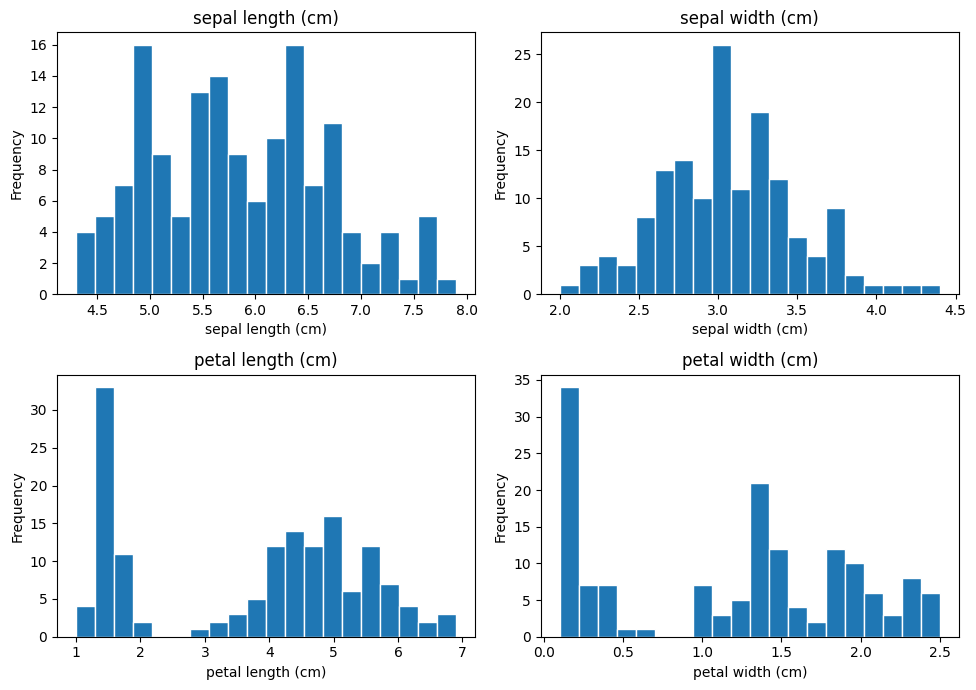

In [28]:
features = ['sepal length (cm)', 'sepal width (cm)',
            'petal length (cm)', 'petal width (cm)']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=20, edgecolor='white')
    axes[i].set_title(feat)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### Bar Plot - Species (Categorical Feature)

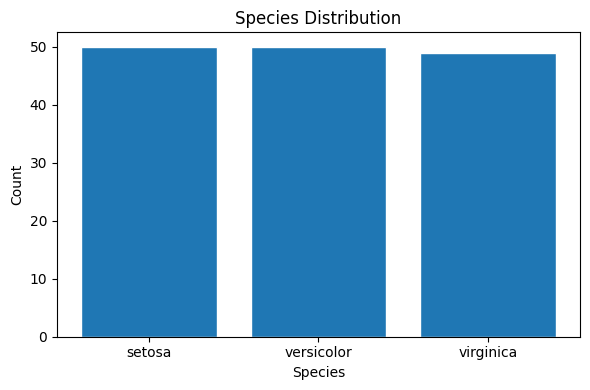

In [29]:
counts = df['species'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, edgecolor='white')
plt.title('Species Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Skewness and Outlier Detection

In [30]:
print("Skewness:")
print(df[features].skew().round(3))


Skewness:
sepal length (cm)    0.313
sepal width (cm)     0.307
petal length (cm)   -0.263
petal width (cm)    -0.090
dtype: float64


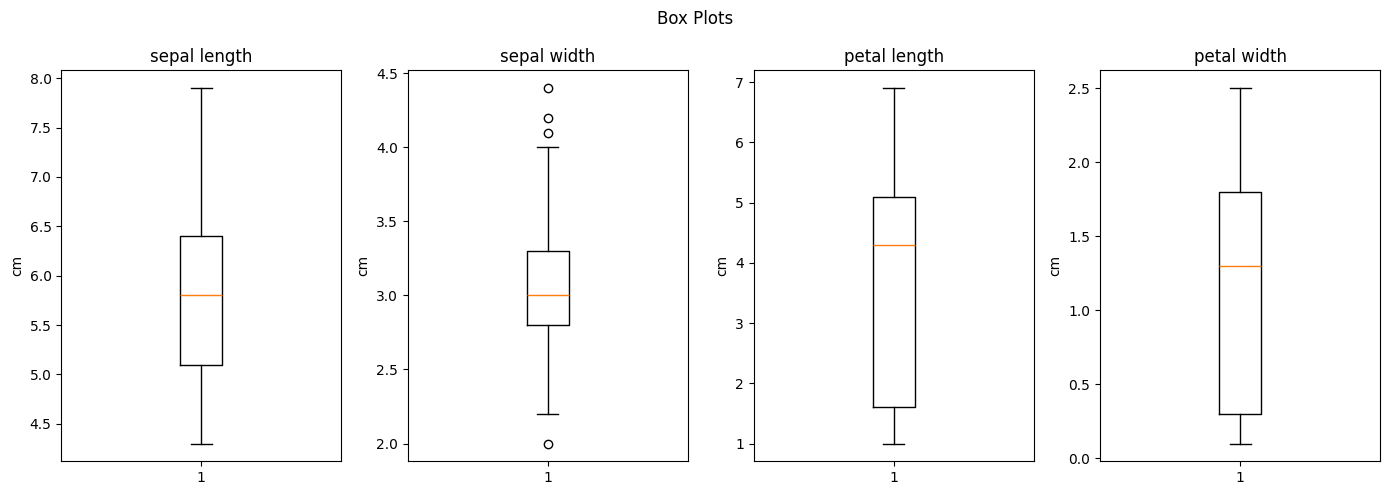

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for i, feat in enumerate(features):
    axes[i].boxplot(df[feat])
    axes[i].set_title(feat.replace(' (cm)', ''))
    axes[i].set_ylabel('cm')

plt.suptitle('Box Plots')
plt.tight_layout()
plt.show()


Sepal width shows a few mild outliers. Petal features are clean. Petal length and petal width both show a bimodal distribution, suggesting two natural groupings in the data -- setosa on one side, versicolor and virginica on the other.

## 4. Bivariate Analysis

### Feature vs. Target - Box Plots per Species

C:\Users\parij\AppData\Local\Temp\ipykernel_4140\2108642044.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(groups, labels=species_list)
C:\Users\parij\AppData\Local\Temp\ipykernel_4140\2108642044.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(groups, labels=species_list)
C:\Users\parij\AppData\Local\Temp\ipykernel_4140\2108642044.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(groups, labels=species_list)
C:\Users\parij\AppData\Local\Temp\ipykernel_4140\2108642044.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick

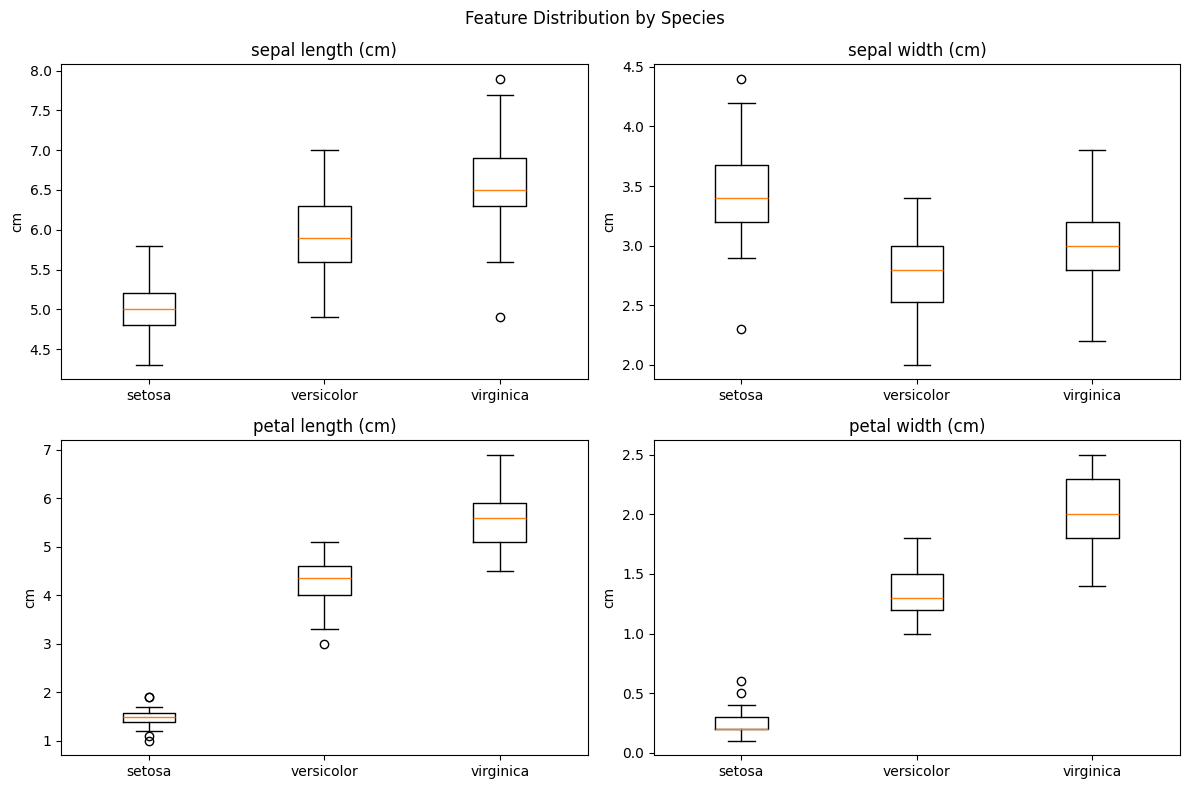

In [32]:
species_list = df['species'].cat.categories.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    groups = [df[df['species'] == sp][feat].values for sp in species_list]
    axes[i].boxplot(groups, labels=species_list)
    axes[i].set_title(feat)
    axes[i].set_ylabel('cm')

plt.suptitle('Feature Distribution by Species')
plt.tight_layout()
plt.show()


### Scatter Plots - Pairwise Relationships

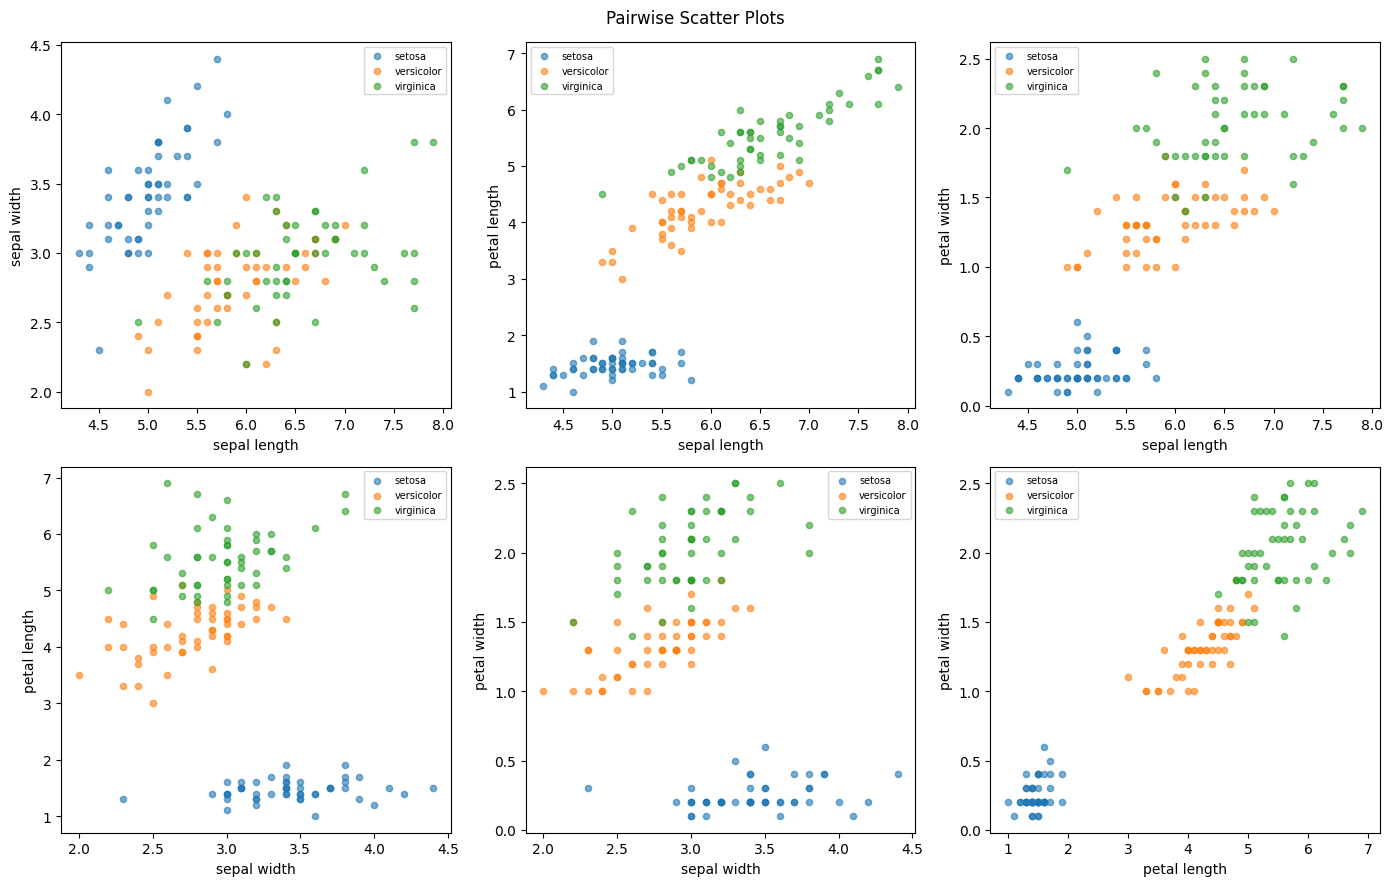

In [33]:
colors = {'setosa': 'tab:blue', 'versicolor': 'tab:orange', 'virginica': 'tab:green'}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

pairs = [(features[i], features[j]) for i in range(4) for j in range(i+1, 4)]

for idx, (fx, fy) in enumerate(pairs):
    for sp, color in colors.items():
        subset = df[df['species'] == sp]
        axes[idx].scatter(subset[fx], subset[fy], label=sp, alpha=0.6, s=20, c=color)
    axes[idx].set_xlabel(fx.replace(' (cm)', ''))
    axes[idx].set_ylabel(fy.replace(' (cm)', ''))
    axes[idx].legend(fontsize=7)

plt.suptitle('Pairwise Scatter Plots')
plt.tight_layout()
plt.show()


## 5. Observations / Answers to questions

### Patterns Found

Iris setosa is clearly separable from the other two species using petal length and petal width alone. Versicolor and virginica overlap in sepal dimensions but remain separable in petal dimensions. The petal feature histograms show two distinct humps, one for setosa and one for the remaining two species.

### Most Important Features

Petal length and petal width show the strongest separation between all three species and are therefore the most useful features for classification. Sepal length offers partial separation. Sepal width overlaps heavily across all three classes and is the least informative feature on its own.

### Surprising Observations

The dataset is perfectly balanced, 50 samples per class, which is unusual for real-world data. Sepal width, which might intuitively seem like a useful size measurement, turns out to be the weakest predictor. The high correlation between petal length and petal width (approximately 0.96) means they carry nearly identical information.

### Preprocessing Before Modeling

- Apply `StandardScaler`, distance-based models like KNN and SVM are sensitive to feature scale.
- Encode the target with `LabelEncoder` or use the integer codes directly.
- Use a stratified train/test split (80/20) to preserve class proportions.
- No imputation needed, the dataset has no missing values.
- No outlier removal needed, the mild outliers in sepal width are likely genuine measurements.
